# 4D SfM — DEM + DoD + M3C2 raster (monthly batch)

Runs the full per-date workflow for one date per month, producing
DEM + orthoimage + DoD + stable-terrain DoD + M3C2 raster (with
histograms) for each date. All logic lives in
`cntp.pipeline_4dsfm.run_4dsfm_day_with_rasters`; this notebook is
just configuration + one loop.

Reference rasters (`reference_dem.tif`, `reference_ortho.tif`,
`reference_dem_stable.tif`) cache in `_ref_cache/` — built on the
first iteration, skipped on every subsequent date.

In [9]:
%load_ext autoreload
%autoreload 2

import os
os.environ["AGISOFT_LICENSE_PATH"] = "/home/asus/.config/Agisoft/license.lic"

from pathlib import Path

import Metashape  # noqa: F401  — must import after AGISOFT_LICENSE_PATH is set
from cntp.pipeline_4dsfm import run_4dsfm_day_with_rasters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

Edit only this section. Paths + dates + all per-stage knobs live here.

In [10]:
# ── Site — edit paths in site_config.py; switch glacier by the name here ─
from site_config import changri_north as site

# ── Dates to process (one per month) ─────────────────────────────────
monthly_dates = [
    # "2024-01-18",
    # "2024-02-18",
    # "2024-03-17",
    # "2024-04-19",
    # "2024-05-17",
    "2024-06-15",
    "2024-07-15",
    "2024-08-17",
    "2024-09-18",
    "2024-10-16",
    "2024-11-15",
]

# ── Per-date knobs (SfM + raster combined) ───────────────────────────
params = dict(
    # SfM pipeline knobs (forwarded to run_4dsfm_day)
    match_downscale       = 1,
    depth_downscale       = 2,
    loc_acc_new           = (0.5, 0.5, 0.5),
    rot_acc_new           = (5.0, 5.0, 5.0),
    ref_downsample        = 0.2,   # per-glacier coreg knob (0.05 North dense / 0.40 West)
    tba_downsample        = 1.0,
    p2p_max_disp          = 10,
    sp2p_max_disp         = 5,
    m_sp2p_max_disp       = 0.5,
    use_ecef              = True,
    overwrite             = False,
    verbose               = True,
    # Registry frozen at the 2023-11-27 baseline (no feedback into BA).
    add_to_registry       = False,
    # Skip Step 6 rebuild + Step 6b validation (coreg M3C2 plot still runs).
    run_validation        = False,

    # Raster knobs
    dem_method            = "point2dem",   # HSfM ASP point2dem (IDW); "cubic" = legacy
    res                   = 1.0,
    max_gap_pixels        = 1,
    ref_cloud_downsample  = 0.25,
    m3c2_ref_downsample   = 0.25,
    slope_threshold       = 60.0,
    overwrite_ref_dem     = False,
    overwrite_day_dem     = False,
    overwrite_dod         = False,
    overwrite_stable      = False,
    overwrite_stable_dod  = False,
    overwrite_m3c2        = False,
)

## Run

Loops over `monthly_dates` and calls `run_4dsfm_day_with_rasters`
for each. Wrapped in `try / except` so a single bad date doesn't
stop the run; per-date stats collected and printed at the end.

In [ ]:
import traceback

summary = []
for d in monthly_dates:
    try:
        summary.append(run_4dsfm_day_with_rasters(
            new_date     = d,
            tlcam_dir    = site.tlcam_dir,
            ref_cloud    = site.ref_cloud,
            glacier_mask = site.glacier_mask,
            registry_csv = site.registry_csv,
            output_dir   = site.output_dir,
            **params,
        ))
    except Exception as e:
        print(f"\n  {d} failed: {type(e).__name__}: {e}")
        traceback.print_exc()
        summary.append({"date": d, "error": repr(e)})

print(f"\n{'='*70}\n  Batch summary ({len(summary)} dates)\n{'='*70}")
for s in summary:
    if "error" in s:
        print(f"  {s['date']} : ERROR — {s['error']}")
    else:
        print(
            f"  {s['date']} : "
            f"DoD med={s['dod_stats']['median']:+.3f} m  std={s['dod_stats']['std']:.3f}  |  "
            f"stable med={s['stable_stats']['median']:+.3f} m  std={s['stable_stats']['std']:.3f}  |  "
            f"M3C2 med={s['m3c2_stats']['median']:+.3f} m  std={s['m3c2_stats']['std']:.3f}"
        )

  Stage 1 — point-to-plane ICP (max_displacement=10 m)
pc_align --threads 16 --max-displacement 10 --alignment-method point-to-plane -o /mnt/g/2023_11_Nepal/2023_Changri/Changri_North/output/2024-01-18/coreg/stage1/run /mnt/g/2023_11_Nepal/2023_Changri/Changri_North/output/_ref_cache/ecef/Reference_UAV_TLC_PCS_ds0.20_ecef.las /mnt/g/2023_11_Nepal/2023_Changri/Changri_North/output/2024-01-18/coreg/ecef/2024-01-18_cloud_ecef.las
	--> Setting number of processing threads to: 16
Writing log: /mnt/g/2023_11_Nepal/2023_Changri/Changri_North/output/2024-01-18/coreg/stage1/run-log-pc_align-06-12-1206-25427.txt
No datum specified. Will write output CSV files in the x,y,z format.
Computing the bounding boxes of the reference and source points using 1000000 sample points.
Computation of bounding boxes took 0.005558 s
Reference points box: Min: (1.79769e+308, 1.79769e+308) width: 0 height: 0
Source points box:    Min: (1.79769e+308, 1.79769e+308) width: 0 height: 0
Intersection box:     Min: (1.79

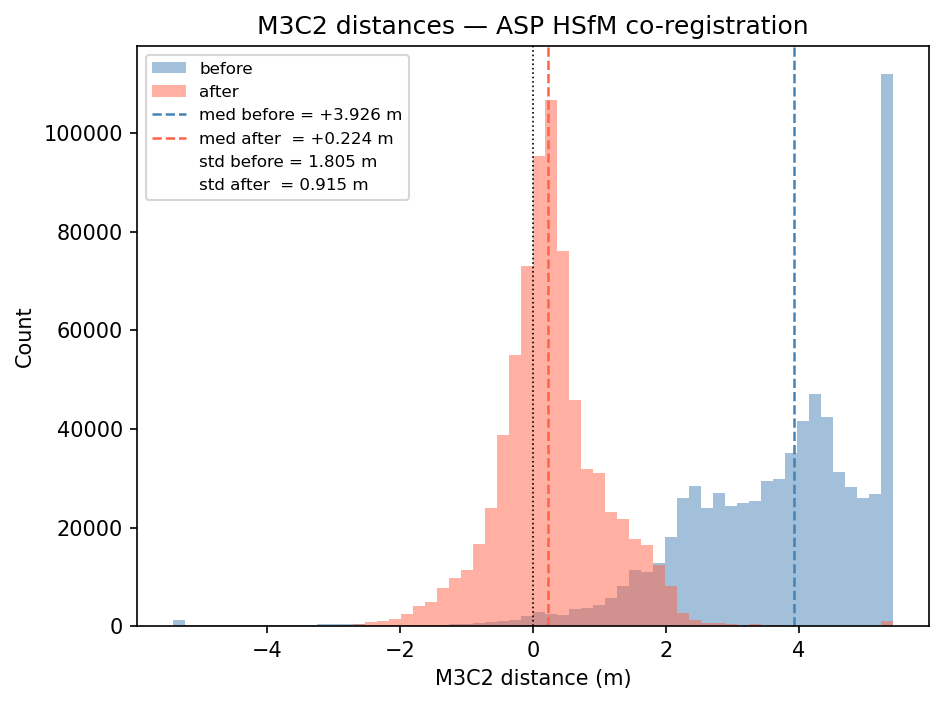

In [18]:
# ── Tune ASP coreg — reuses cached single-day clouds (no SfM) ─────────
from cntp.asp import pc_align_p2p_sp2p, evaluate_coreg
from cntp.metashape import _utm_epsg
from IPython.display import Image
import pandas as pd, time

tune_dates = [ 
    "2024-01-18",
    "2024-02-18",
    "2024-03-17",
    "2024-04-19",
    "2024-05-17",
    "2024-06-15",
    "2024-07-15",
    "2024-08-17",
    "2024-09-18",
    "2024-10-16",
    "2024-11-15",
]              # date(s) to tune on
asp = dict(                              # ← tweak these and re-run the cell
    p2p_max_displacement    = 10,
    sp2p_max_displacement   = 5,
    m_sp2p_max_displacement = 0.5,       # Stage-3 cap — the sensitive one
)

rds = params["ref_downsample"]           # must match what built _ref_cache
tbd = params["tba_downsample"]
utm  = _utm_epsg(pd.read_csv(site.registry_csv)["lon"].mean())
ecef = utm if params["use_ecef"] else None
cache = site.out / "_ref_cache"
stem  = f"{site.ref_cloud.stem}_ds{rds:.2f}"
ref_ds, stable_ref = cache / f"{stem}.las", cache / f"{stem}_stable.las"

for d in tune_dates:
    tba = site.out / d / "single_day" / f"{d}_cloud.las"
    cdir = site.out / d / "coreg"
    t = time.time()
    aligned, _ = pc_align_p2p_sp2p(
        tba_las=tba, ref_las=ref_ds, output_dir=cdir, stable_ref_las=stable_ref,
        ref_downsample_factor=1.0, tba_downsample_factor=tbd,
        utm_epsg=ecef, verbose=True, **asp)
    ev = evaluate_coreg(
        ref_las=ref_ds, tba_before_las=tba, tba_after_las=aligned,
        ref_downsample_factor=1.0, tba_downsample_factor=tbd,
        glacier_mask_path=site.glacier_mask, stable_ref_las=stable_ref,
        stable_dir=cdir / "stable_tba", plot_dir=cdir / "m3c2_plots")
    print(f"  {d}: stable M3C2 before {ev['med_before']:+.4f} → after {ev['med_after']:+.4f} m  "
          f"(std {ev['std_before']:.3f} → {ev['std_after']:.3f})  [{time.time()-t:.0f}s]")

Image(filename=str(cdir / "m3c2_plots" / "m3c2_distances.png"))   # last date's plot
